# LOF anomalies in umap

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import joblib
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import umap

from anomaly.utils import specobjid_to_idx
from sdss.metadata import MetaData

meta = MetaData()

# Custom Functions

## Scale data

In [3]:
def standard_scaler(latent_arr):

    scaler = StandardScaler()
    
    latent_scaled = scaler.fit_transform(latent_arr)
    
    return latent_scaled

## Score to df

In [4]:
def score_arr_to_df(score_path, bin_idx_to_specobjid):

    score_name = score_path.split("/")[-1][:-4]
    objids_bin = bin_idx_to_specobjid[:, 1]

    print(f"Loading score: {score_name}")
    raw_score = {'neg_lof': np.load(score_path)}

    score_df = pd.DataFrame(data=raw_score, index=objids_bin)
    score_df.index.name = 'specobjid'

    return score_df

## specids from top anomalies

In [5]:
def specids_from_lof_scores(score_df, quantile=0.99):

    threshold = score_df['lof'].quantile(quantile)
    top_k = (score_df['lof'] >= threshold).sum()

    top_k_specids = score_df.sort_values(
        by='lof', ascending=False
    ).head(top_k).index.to_numpy()

    return top_k_specids

# Config

## Directories

In [6]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
ch4_dir = f"{thesis_dir}/chapters/04_figures"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
bins_ids = [f'bin_{i:02d}' for i in range(4)] 

## Data

In [7]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

# LOF scores
The consensus-based strategy made LOF models winners to have
```python
n=60 and metric='manhattan'
```

## Load scores & append metadata

In [8]:
scores_df_dict = {}
# lof_model_dict = {}
n = 60
metric = 'manhattan'

for bin_id in bins_ids:

    # load df of scores
    _df = pd.read_csv(
        f"{latent_dir}/{bin_id}/"
        f"lof_scores_{bin_id}_n{n}_{metric}.csv",
        index_col='specobjid'
    )

    scores_df_dict[bin_id] = _df.join(
        final_meta_df[['z', 'snMedian']],
        how='inner'
    ).copy()

## Load Umap

In [9]:
umap_dict = {}

for bin_id in bins_ids:

    # load df of scores
    umap_dict[bin_id] = np.load(
        f"{latent_dir}/{bin_id}/"
        f"umap_latent_{bin_id}.npy",
    )

# LOF in embedding

In [10]:
def specids_from_lof_scores(score_df, quantile=0.99):

    threshold = score_df['lof'].quantile(quantile)
    top_k = (score_df['lof'] >= threshold).sum()

    top_k_specids = score_df.sort_values(
        by='lof', ascending=False
    ).head(top_k).index.to_numpy()

    return top_k_specids

## bin_03

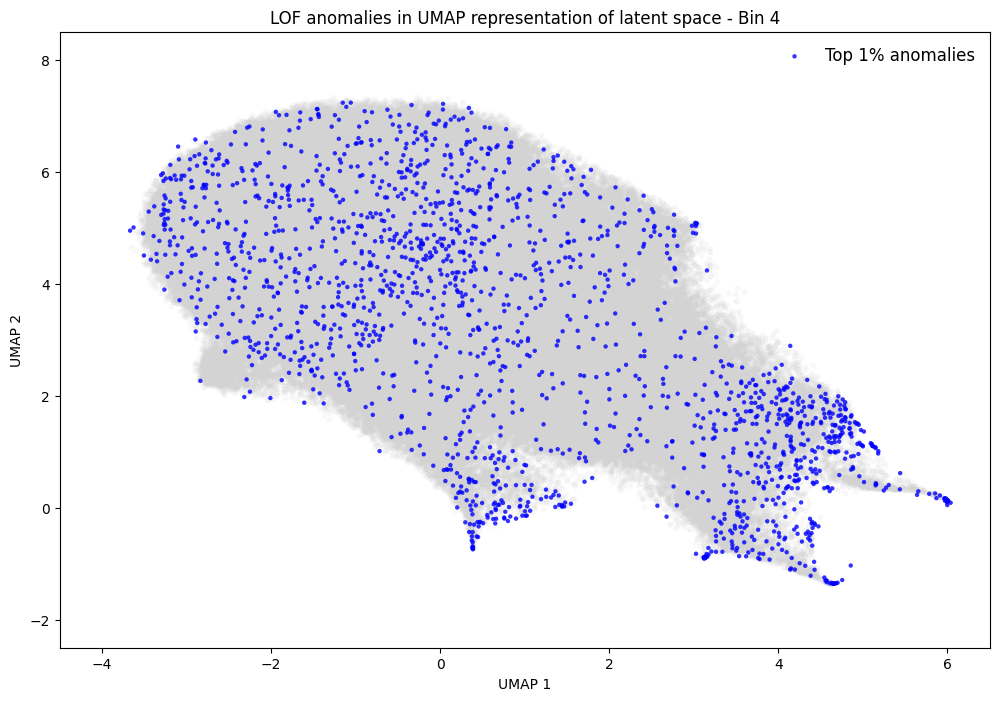

In [13]:
bin_id = 'bin_03'
bin_number = int(bin_id.split('_')[1])
score_df = scores_df_dict[bin_id].copy()

spec_ids_anomalies = specids_from_lof_scores(score_df)
is_anomaly_mask = score_df.index.isin(spec_ids_anomalies)
anomaly_threshold = score_df['lof'].quantile(0.99)
spec_ids_inliers = score_df[score_df['lof'] < anomaly_threshold].index.to_numpy()
is_inlier_mask = score_df.index.isin(spec_ids_inliers)

# prepare embeddings
embedding = umap_dict[bin_id]
embedding_anomalies = embedding[is_anomaly_mask, :]
embedding_inliers = embedding[is_inlier_mask, :]

# figure

fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 8)
)

plt.scatter(
    embedding_inliers[:, 0], 
    embedding_inliers[:, 1], 
    c='lightgrey', 
    s=10, 
    alpha=0.1,
    # label='Inliers (99%)',
    # rasterized=True
)

# --- Layer 2: The Anomalies ---
scatter_anom = plt.scatter(
    embedding_anomalies[:, 0], 
    embedding_anomalies[:, 1], 
    c='blue',
    s=10,
    alpha=0.8, 
    edgecolors='none',
    label='Top 1% anomalies'
)

plt.legend(fontsize=12, frameon=False)

# x and y labels
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

# title
title = (
    f"LOF anomalies in UMAP representation of latent space - "
    f"Bin {bin_number+1}"
)
ax.set_title(title)

# -------------------------------------------------------------
x_ticks = [-4, -2, 0, 2, 4, 6]
ax.set_xticks(x_ticks)
x_limits = (-4.5, 6.5)
ax.set_xlim(x_limits)

y_ticks = [-2, 0, 2, 4, 6, 8]
ax.set_yticks(y_ticks)
y_limits = (-2.5, 8.5)
ax.set_ylim(y_limits)
# -------------------------------------------------------------

# save figure
fig.savefig(
    f"{ch4_dir}/{bin_id}/latent/lof_anomalies_umap_{bin_id}.pdf",
    bbox_inches='tight'
)

## bin_02

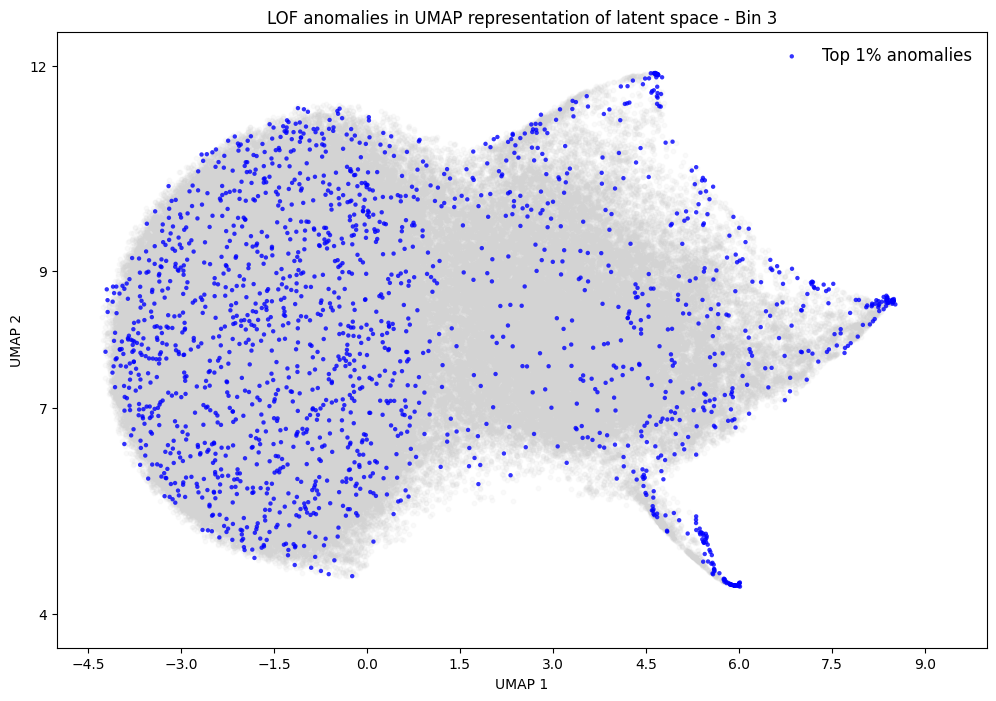

In [14]:
bin_id = 'bin_02'
bin_number = int(bin_id.split('_')[1])
score_df = scores_df_dict[bin_id].copy()

spec_ids_anomalies = specids_from_lof_scores(score_df)
is_anomaly_mask = score_df.index.isin(spec_ids_anomalies)
anomaly_threshold = score_df['lof'].quantile(0.99)
spec_ids_inliers = score_df[score_df['lof'] < anomaly_threshold].index.to_numpy()
is_inlier_mask = score_df.index.isin(spec_ids_inliers)

# prepare embeddings
embedding = umap_dict[bin_id]
embedding_anomalies = embedding[is_anomaly_mask, :]
embedding_inliers = embedding[is_inlier_mask, :]

# figure

fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 8)
)

plt.scatter(
    embedding_inliers[:, 0], 
    embedding_inliers[:, 1], 
    c='lightgrey', 
    s=10, 
    alpha=0.1,
    # label='Inliers (99%)',
    # rasterized=True
)

# --- Layer 2: The Anomalies ---
scatter_anom = plt.scatter(
    embedding_anomalies[:, 0], 
    embedding_anomalies[:, 1], 
    c='blue',
    s=10,
    alpha=0.8, 
    edgecolors='none',
    label='Top 1% anomalies'
)

plt.legend(fontsize=12, frameon=False)

# x and y labels
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

# title
title = (
    f"LOF anomalies in UMAP representation of latent space - "
    f"Bin {bin_number+1}"
)
ax.set_title(title)


# -------------------------------------------------------------
x_ticks = [-4.5, -3, -1.5, 0, 1.5, 3, 4.5, 6, 7.5, 9]
ax.set_xticks(x_ticks)
x_limits = (-5, 10)
ax.set_xlim(x_limits)

y_ticks = [4, 7, 9, 12]
ax.set_yticks(y_ticks)
y_limits = (3.5, 12.5)
ax.set_ylim(y_limits)
# -------------------------------------------------------------
# save figure
fig.savefig(
    f"{ch4_dir}/{bin_id}/latent/lof_anomalies_umap_{bin_id}.pdf",
    bbox_inches='tight'
)

## bin_01

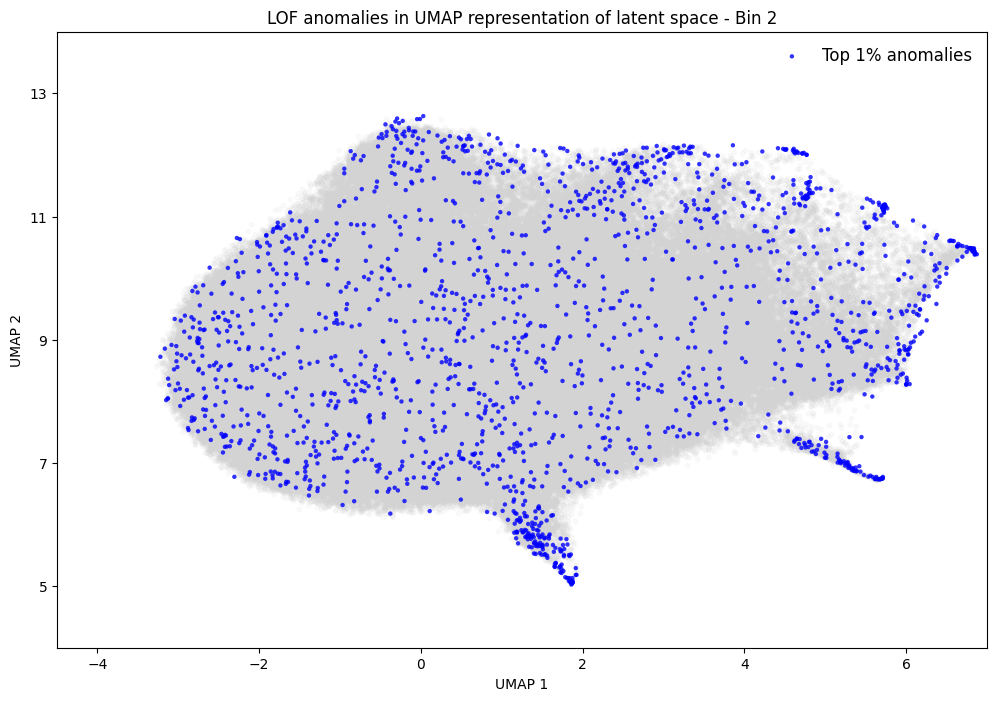

In [15]:
bin_id = 'bin_01'
bin_number = int(bin_id.split('_')[1])
score_df = scores_df_dict[bin_id].copy()

spec_ids_anomalies = specids_from_lof_scores(score_df)
is_anomaly_mask = score_df.index.isin(spec_ids_anomalies)
anomaly_threshold = score_df['lof'].quantile(0.99)
spec_ids_inliers = score_df[score_df['lof'] < anomaly_threshold].index.to_numpy()
is_inlier_mask = score_df.index.isin(spec_ids_inliers)

# prepare embeddings
embedding = umap_dict[bin_id]
embedding_anomalies = embedding[is_anomaly_mask, :]
embedding_inliers = embedding[is_inlier_mask, :]

# figure

fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 8)
)

plt.scatter(
    embedding_inliers[:, 0], 
    embedding_inliers[:, 1], 
    c='lightgrey', 
    s=10, 
    alpha=0.1,
    # label='Inliers (99%)',
    # rasterized=True
)

# --- Layer 2: The Anomalies ---
scatter_anom = plt.scatter(
    embedding_anomalies[:, 0], 
    embedding_anomalies[:, 1], 
    c='blue',
    s=10,
    alpha=0.8, 
    edgecolors='none',
    label='Top 1% anomalies'
)
plt.legend(fontsize=12, frameon=False)

# x and y labels
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

# title
title = (
    f"LOF anomalies in UMAP representation of latent space - "
    f"Bin {bin_number+1}"
)
ax.set_title(title)

# -------------------------------------------------------------
x_ticks = [-4, -2, 0, 2, 4, 6]
ax.set_xticks(x_ticks)
x_limits = (-4.5, 7)
ax.set_xlim(x_limits)

y_ticks = [5, 7, 9, 11, 13]
ax.set_yticks(y_ticks)
y_limits = (4, 14)
ax.set_ylim(y_limits)
# -------------------------------------------------------------


# save figure
fig.savefig(
    f"{ch4_dir}/{bin_id}/latent/lof_anomalies_umap_{bin_id}.pdf",
    bbox_inches='tight'
)

## bin_00

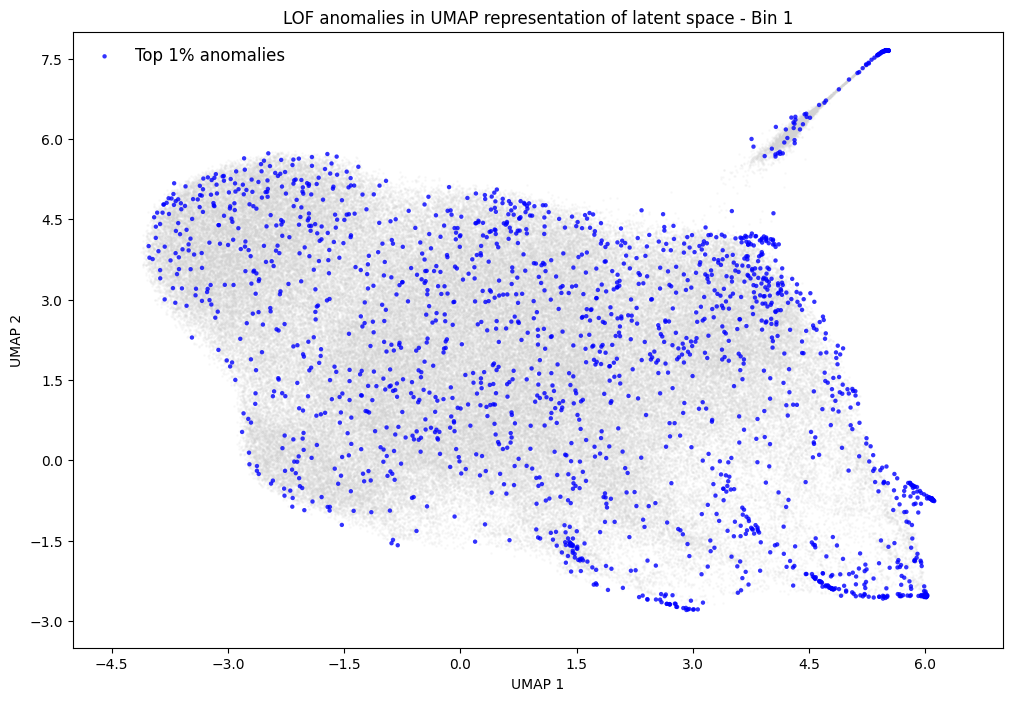

In [16]:
bin_id = 'bin_00'
bin_number = int(bin_id.split('_')[1])
score_df = scores_df_dict[bin_id].copy()

spec_ids_anomalies = specids_from_lof_scores(score_df)
is_anomaly_mask = score_df.index.isin(spec_ids_anomalies)
anomaly_threshold = score_df['lof'].quantile(0.99)
spec_ids_inliers = score_df[score_df['lof'] < anomaly_threshold].index.to_numpy()
is_inlier_mask = score_df.index.isin(spec_ids_inliers)

# prepare embeddings
embedding = umap_dict[bin_id]
embedding_anomalies = embedding[is_anomaly_mask, :]
embedding_inliers = embedding[is_inlier_mask, :]

# figure

fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 8)
)

plt.scatter(
    embedding_inliers[:, 0], 
    embedding_inliers[:, 1], 
    c='lightgrey', 
    s=1, 
    alpha=0.1,
    # label='Inliers (99%)',
    # rasterized=True
)

# --- Layer 2: The Anomalies ---
scatter_anom = plt.scatter(
    embedding_anomalies[:, 0], 
    embedding_anomalies[:, 1], 
    c='blue',
    s=10,
    alpha=0.8, 
    edgecolors='none',
    label='Top 1% anomalies'
)
plt.legend(fontsize=12, frameon=False)

# x and y labels
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

# title
title = (
    f"LOF anomalies in UMAP representation of latent space - "
    f"Bin {bin_number+1}"
)
ax.set_title(title)

# -------------------------------------------------------------
x_ticks = [-4.5, -3, -1.5, 0, 1.5, 3, 4.5, 6]
ax.set_xticks(x_ticks)
x_limits = (-5, 7)
ax.set_xlim(x_limits)

y_ticks = [-3, -1.5, 0, 1.5, 3, 4.5, 6, 7.5]
ax.set_yticks(y_ticks)
y_limits = (-3.5, 8)
ax.set_ylim(y_limits)
# -------------------------------------------------------------


# save figure
fig.savefig(
    f"{ch4_dir}/{bin_id}/latent/lof_anomalies_umap_{bin_id}.pdf",
    bbox_inches='tight'
)